# Vector Field - Reactive Algorithms - Spring with Steam

## A Stream with a Spring

This one is going to have less visualizations than the first.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Define Constants

In [2]:
# 2. Define constants
def reset_constants():
    global x_start, y_start, x_end, y_end, quiver_step_size, angle, robot_offset
    global x_source, y_source, robot_1_start, robot_2_offset, robot_3_offset, robot_step_size
    global stop_simulation, flaggs
    
    x_start = y_start = 0
    x_end = y_end = 10
    quiver_step_size = 0.2

    x_source = 3 
    y_source = 5

    robot_1_start = [8,7.5]
    robot_2_offset = [0.3,0]
    robot_3_offset = [0,0.3]

    robot_step_size = 0.3
    angle = 0 # Needed for initialization for some reason
    robot_offset = 0.5 # Spacing for alignment
    stop_simulation = False
    flaggs = False

## 3. Define Flows and Robot Movements

In [8]:
def spring_stream(x, y, x_source, y_source):
    
    # Establishing a Uniform Flow
    u = np.ones_like(x)  
    v = np.zeros_like(x)  


    # Calculating A Source
    x_centre = x - x_source
    y_centre = y - y_source
    r = np.sqrt(x_centre**2 + y_centre**2)
    r[r==0] = 1e-6

    # Adding the uniform flow to the spring source
    u = u + x_centre / r**2
    v = v + y_centre / r**2

    return u, v

def robot_readings(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source
    
    # Calculate the distance r from the center
    dist = np.sqrt((x-x_source)**2 + (y-y_source)**2)
    
    # Establishing a Uniform Flow
    u = np.ones_like(x)  
    v = np.zeros_like(x) 
    
    # Adding the uniform flow to the spring source
    u = u + x_centre / dist**2
    v = v + y_centre / dist**2
                   
    return u, v

def composite_vector(u,v):
    
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v,u)  
    
    return mag, angle

def plot_robot_position(pos1,pos2,pos3):

    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    
    
def max_flow_finder(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, robot_step_size, angle):
    if np.sign(slope_y)>0:
        pos1[1] += robot_step_size
        pos2[1] += robot_step_size
        pos3[1] += robot_step_size
    else:
        pos1[1] -= robot_step_size
        pos2[1] -= robot_step_size
        pos3[1] -= robot_step_size
    return pos1, pos2, pos3
    
def spring_finder(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, step_size, angle):
    
    angle = np.arctan2(slope_y,slope_x) #- np.pi/2
    
    
    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    return pos1, pos2, pos3

def fast_flow_aligned(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, step_size, angle):

    
    if np.sign(slope_y1)>0 and np.sign(slope_y2)>0:
        pos1[1] += step_size
        pos2[1] += step_size
        pos3[1] += step_size
    elif np.sign(slope_y1)<0 and np.sign(slope_y2)<0:
        pos1[1] -= step_size
        pos2[1] -= step_size
        pos3[1] -= step_size
    return pos1, pos2, pos3

def stagnation_finder(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, step_size, angle):
    
    global flaggs
    
    angle = np.arctan2(slope_y,slope_x)

    readings = [robot_readings(pos[0], pos[1], x_source, y_source) for pos in [pos1, pos2, pos3]]
    composites = [composite_vector(u, v) for u, v in readings]
   


    if (np.absolute(angle)<0.1) or flaggs:
        
        print()
        composites = [(10 - comp[0], comp[1]) for comp in composites]
        slope_x = (composites[1][0] - composites[0][0])/ robot_2_offset[0]
        slope_y = (composites[2][0] - composites[0][0]) / robot_3_offset[1]
        angle = np.arctan2(slope_y,slope_x) #+ np.pi/2
        pos1[0] += step_size*np.cos(angle)
        pos1[1] += step_size*np.sin(angle)
        pos2[0] += step_size*np.cos(angle)
        pos2[1] += step_size*np.sin(angle)
        pos3[0] += step_size*np.cos(angle)
        pos3[1] += step_size*np.sin(angle)
        flaggs = True
    
    else:
        angle -= np.pi/2
        #angle = np.arctan2(slope_y,slope_x)
        pos1[0] += step_size*np.cos(angle)
        pos1[1] += step_size*np.sin(angle)
        pos2[0] += step_size*np.cos(angle)
        pos2[1] += step_size*np.sin(angle)
        pos3[0] += step_size*np.cos(angle)
        pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3


def initialize_vortex_field(x_start, x_end, quiver_step_size, y_start, y_end, x_source, y_source):
    x = np.arange(x_start, x_end, quiver_step_size)
    y = np.arange(y_start, y_end, quiver_step_size)
    X, Y = np.meshgrid(x, y)
    u, v = spring_stream(X, Y, x_source, y_source)
    return x, y, u, v

def initialize_robots(robot_1_start, robot_2_offset, robot_3_offset):
    pos1 = robot_1_start
    pos2 = [(robot_1_start[0] + robot_2_offset[0]),(robot_1_start[1] + robot_2_offset[1])]
    pos3 = [(robot_1_start[0] + robot_3_offset[0]),(robot_1_start[1] + robot_3_offset[1])]
    angle = 0
    return pos1, pos2, pos3, angle

def alignment_step(robot_1_start, robot_offset, x_source, y_source):
    # Doing a rotation step prior to the main loop.

    pos1 = robot_1_start
    [u1, v1] = robot_readings(pos1[0],pos1[1], x_source, y_source)
    pos2 = [pos1[0] + robot_offset, pos1[1] + robot_offset]
    [u2, v2] = robot_readings(pos2[0],pos2[1], x_source, y_source)
    pos3 = [pos2[0] + robot_offset, pos2[1] + robot_offset]
    [u3, v3] = robot_readings(pos3[0],pos3[1], x_source, y_source)

    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)

    angle = (angle1+angle2+angle3)/3 +np.pi/2

    pos1 = robot_1_start
    pos2 = [pos1[0] + robot_offset*np.cos(angle),pos1[1] + robot_offset*np.sin(angle)]
    pos3 = [pos2[0] + robot_offset*np.cos(angle),pos2[1] + robot_offset*np.sin(angle)]

    return pos1, pos2, pos3, angle


## Main Function

In [9]:
def execute_simulation(update_robot_position, title):
    # Initialize
    x, y, u, v = initialize_vortex_field(x_start, x_end, quiver_step_size, y_start, y_end, x_source, y_source)
    pos1, pos2, pos3, angle = initialize_robots(robot_1_start, robot_2_offset, robot_3_offset)
    print(' Initial Positions', pos1, pos2, pos3)
    # Initialize output Plot
    plt.figure(figsize=(6, 6))
    plot_robot_position(pos1, pos2, pos3)
    print(title)
    
    if title == 'Fast Flow Aligned':
        pos1, pos2, pos3, angle = alignment_step(robot_1_start, robot_offset, x_source, y_source)

    # Main
    for _ in range(1, 60):
        readings = [robot_readings(pos[0], pos[1], x_source, y_source) for pos in [pos1, pos2, pos3]]
        composites = [composite_vector(u, v) for u, v in readings]
        
        slope_x = (composites[1][0] - composites[0][0])/ robot_2_offset[0]
        slope_y = (composites[2][0] - composites[0][0]) / robot_3_offset[1] 
        slope_y1 = (composites[1][0] - composites[0][0]) / robot_2_offset[0]
        slope_y2 = (composites[2][0] - composites[1][0]) / (robot_3_offset[1] - robot_2_offset[1])
        
        #print(slope_y1)
        plot_robot_position(pos1, pos2, pos3)
       

        pos1, pos2, pos3 = update_robot_position(pos1, pos2, pos3, slope_y, slope_y1, slope_y2, slope_x, robot_step_size, angle)

        
    # Plot Outcome
    plt.quiver(x, y, u, v)
    plt.title(title)
    plt.show()

 Initial Positions [8, 7.5] [8.3, 7.5] [8, 7.8]
Max Flow Finder


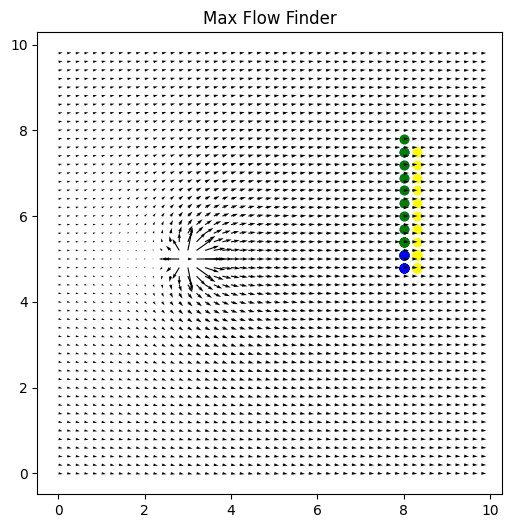

 Initial Positions [8, 7.5] [8.3, 7.5] [8, 7.8]
Spring Finder


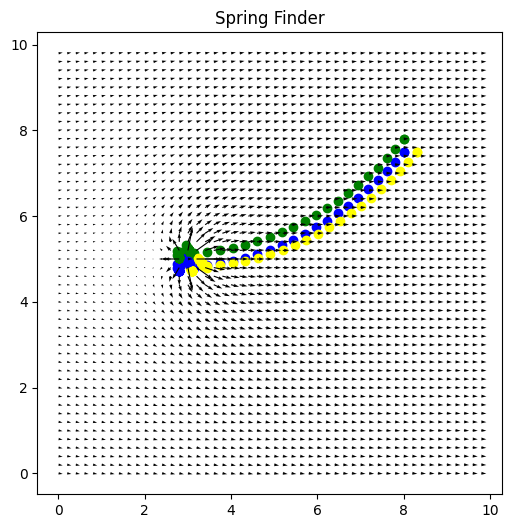

 Initial Positions [8, 7.5] [8.3, 7.5] [8, 7.8]
Fast Flow Aligned


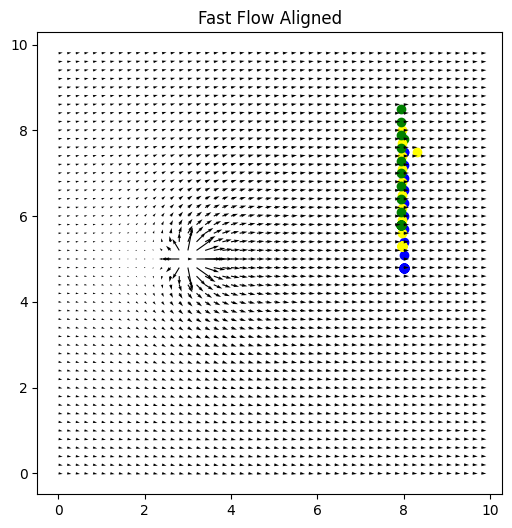

 Initial Positions [8, 7.5] [8.3, 7.5] [8, 7.8]
Stagnation Finder
-2.265250500859562 [8, 7.5]
-2.182339541510593 [7.769479062096603, 7.691989836158423]
-2.099320123981108 [7.523850166686199, 7.864229337259259]
-2.015816716841384 [7.264784446721914, 8.015507071045123]
-1.9314441542487015 [6.994003880276221, 8.144649956390579]
-1.8458181247096657 [6.7133033559605595, 8.250514094080886]
-1.7585692328350289 [6.424577572487778, 8.331984468807095]
-1.6693620282549324 [6.129850850708742, 8.387985892622767]
-1.5779201605822877 [5.831306950903111, 8.417507747050381]
-1.4840580712971378 [5.531314563222092, 8.419644879110269]
-1.3877181152389941 [5.232442384601679, 8.393656019060474]
-1.2890095722535697 [4.937456002118449, 8.33903885921618]
-1.188242904516685 [4.649287964683543, 8.255617146209824]
-1.0859497814057153 [4.370973616907536, 8.143629987026213]
-0.9828785545171828 [4.105549672753245, 8.003808208073218]
-0.8799579150898776 [3.8559204685734567, 7.837419324969312]
-0.7782290367185738 [3.6

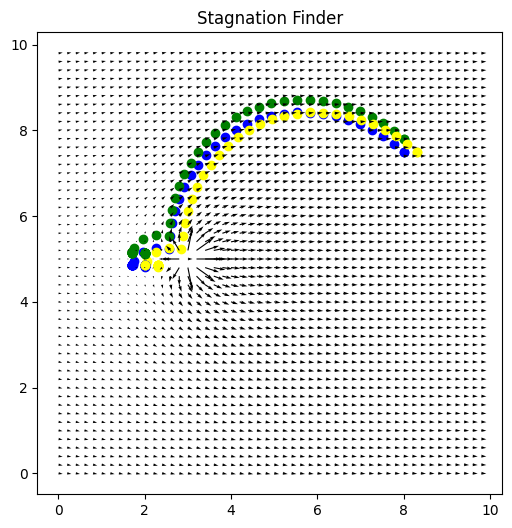

In [10]:
# 5. Execute the simulations
reset_constants()
execute_simulation(max_flow_finder, 'Max Flow Finder')
reset_constants()
execute_simulation(spring_finder, 'Spring Finder')
reset_constants()
execute_simulation(fast_flow_aligned, 'Fast Flow Aligned')
reset_constants()
execute_simulation(stagnation_finder, 'Stagnation Finder')


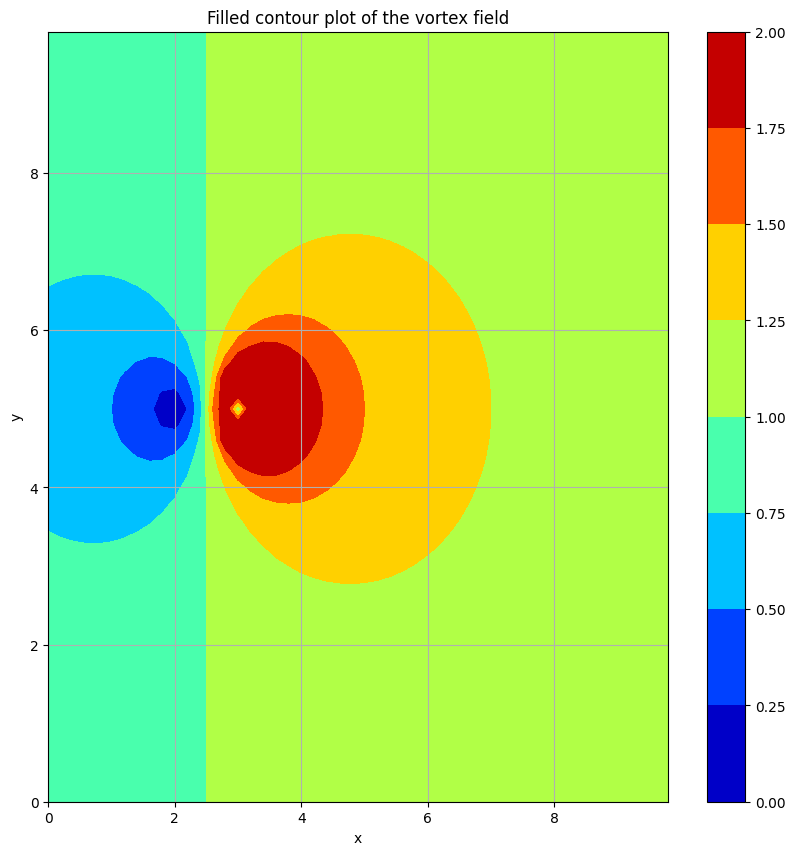

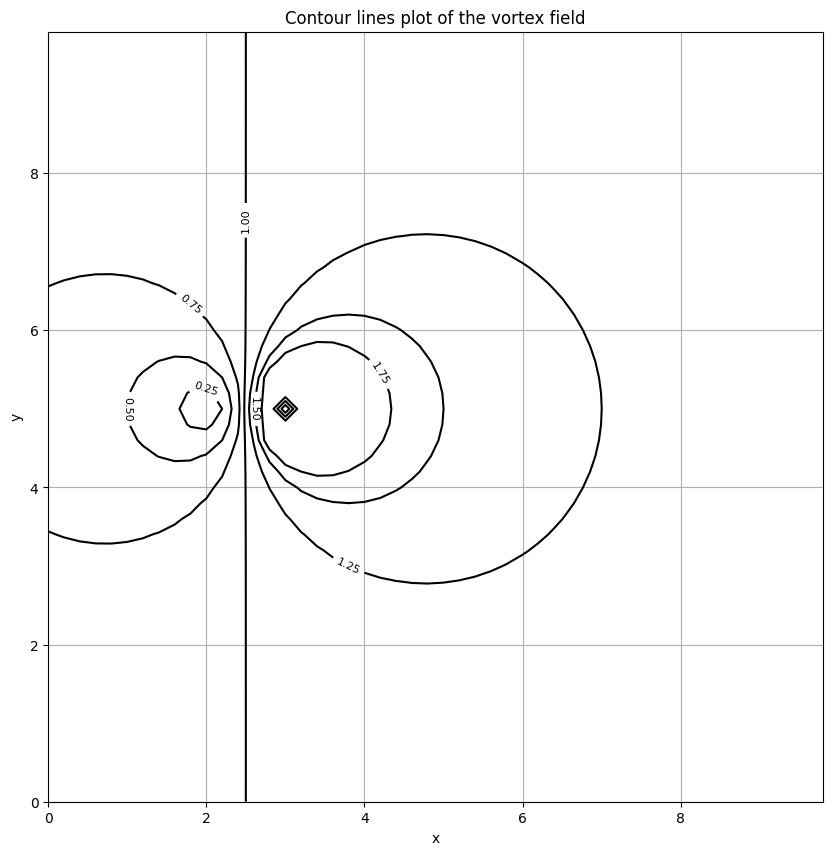

In [6]:
import numpy as np

def plot_vortex_field(x, y, u, v):
    # Generate the magnitude of the vortex field and limit to max value of 3
    mag_uv = np.sqrt(u**2 + v**2)
    mag_uv = np.where(mag_uv > 2, 2, mag_uv)

    # Generate the filled contour plot with a colorbar
    plt.figure(figsize=(10,10))
    filled_contour = plt.contourf(x, y, mag_uv, cmap='jet') 
    plt.colorbar(filled_contour)
    plt.title('Filled contour plot of the vortex field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()
    
    # Generate the contour line plot
    plt.figure(figsize=(10,10))
    line_contour = plt.contour(x, y, mag_uv, colors='black') 
    plt.clabel(line_contour, inline=True, fontsize=8)
    plt.title('Contour lines plot of the vortex field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

# Your initialization and calculation of the vortex field
x_start = 0
x_end = 10
quiver_step_size = 0.2
y_start = 0
y_end = 10
x_source = 3 
y_source = 5

x, y, u, v = initialize_vortex_field(x_start, x_end, quiver_step_size, y_start, y_end, x_source, y_source)

# Call the plot function
plot_vortex_field(x, y, u, v)


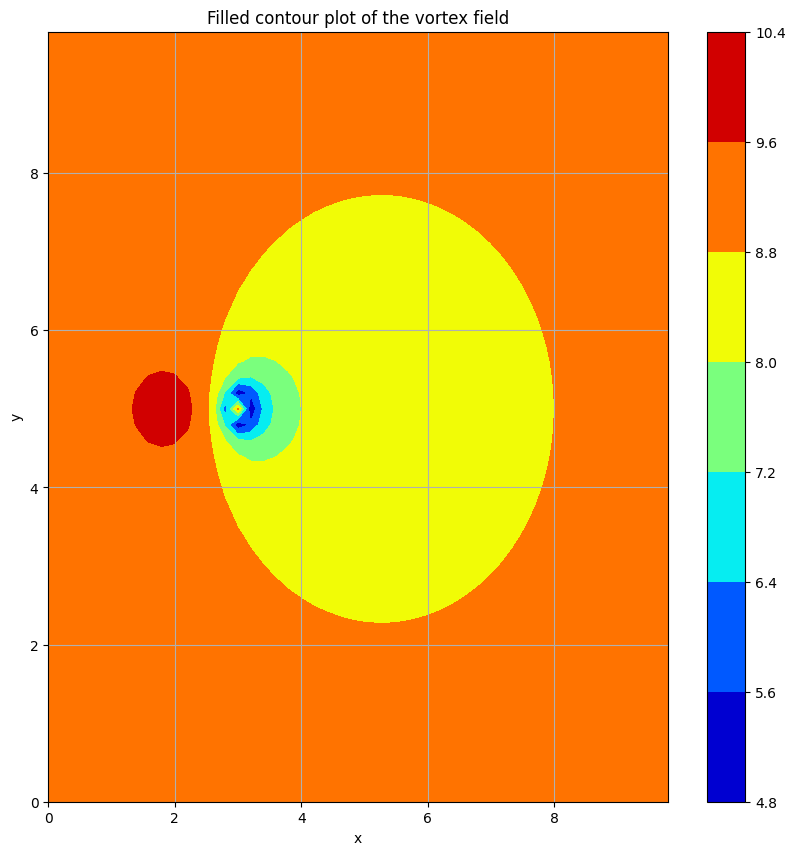

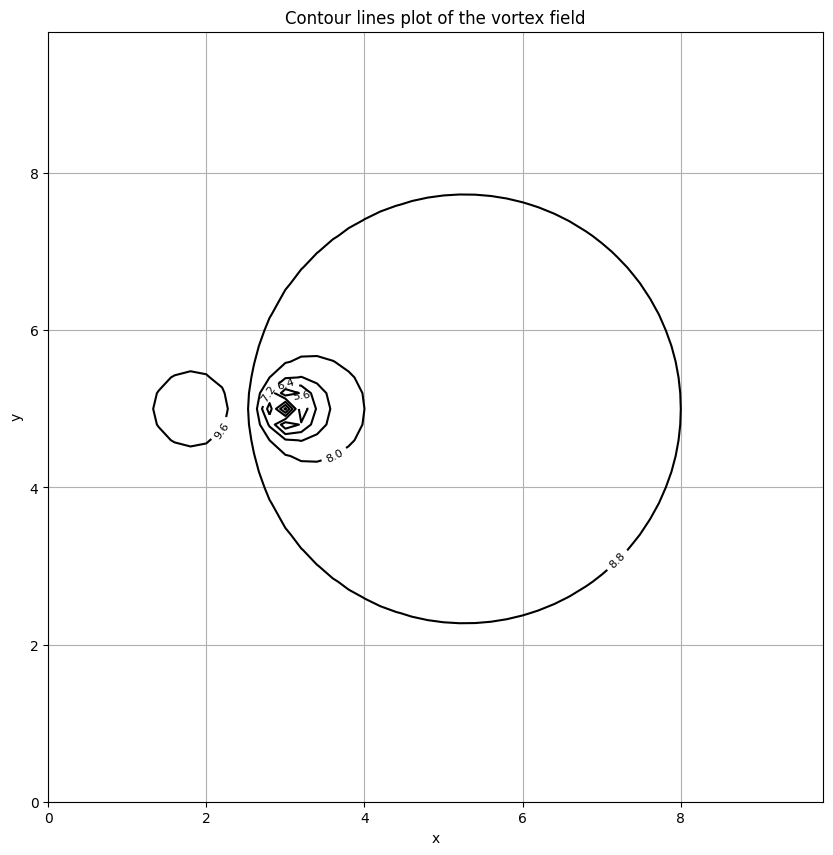

In [7]:
import numpy as np

def plot_vortex_field(x, y, u, v):
    # Generate the magnitude of the vortex field and limit to max value of 3
    mag_uv = np.sqrt(u**2 + v**2)
    mag_uv = 10 - mag_uv
    mag_uv = np.where(mag_uv < 5, 5, mag_uv)

    # Generate the filled contour plot with a colorbar
    plt.figure(figsize=(10,10))
    filled_contour = plt.contourf(x, y, mag_uv, cmap='jet') 
    plt.colorbar(filled_contour)
    plt.title('Filled contour plot of the vortex field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()
    
    # Generate the contour line plot
    plt.figure(figsize=(10,10))
    line_contour = plt.contour(x, y, mag_uv, colors='black') 
    plt.clabel(line_contour, inline=True, fontsize=8)
    plt.title('Contour lines plot of the vortex field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

# Your initialization and calculation of the vortex field
x_start = 0
x_end = 10
quiver_step_size = 0.2
y_start = 0
y_end = 10
x_source = 3 
y_source = 5

x, y, u, v = initialize_vortex_field(x_start, x_end, quiver_step_size, y_start, y_end, x_source, y_source)

# Call the plot function
plot_vortex_field(x, y, u, v)
